# Interpretable Rule-Based ML for TLR4 Activity Prediction

## Purpose

This notebook implements rule-based interpretable machine learning for TLR4 ligand
activity prediction. While Random Forest (Notebook 01) is a powerful ensemble model,
its predictions cannot be expressed as simple human-readable rules. A Decision Tree
can — making it the preferred model when the goal is to communicate findings to
experimental collaborators or medicinal chemists who need to understand *why* a
compound is predicted to be active.

## Workflow
1. Retrieve and curate TLR4 ChEMBL data (same pipeline as Notebook 01)
2. Generate ECFP4 fingerprints and binary activity labels
3. Train a shallow Decision Tree classifier (max_depth=4)
4. Visualize the full decision tree
5. Extract explicit IF–THEN rules from all leaf paths
6. Map rule-critical fingerprint bits back to chemical substructures
7. Compare Decision Tree vs. Random Forest (interpretability–accuracy trade-off)

## Scientific Rationale

Rule-based models produce statements like:
> **IF** bit_1423 = 1 **AND** bit_0876 = 0 **THEN** TLR4 active (confidence: 78%)

Such rules are directly actionable for a synthetic chemist — they can assess whether a
proposed compound satisfies the rule without running any software. This is the practical
utility of interpretable ML in drug discovery.



## Step 1: Install Dependencies

In [1]:
!pip install chembl-webresource-client rdkit dtreeviz -q

print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 440.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.4 MB/s eta 0:00:00
Dependencies installed.


## Step 2: Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, AllChem, Draw
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)
from IPython.display import display

print("Imports complete.")

Imports complete.


## Step 3: Data Retrieval and Curation (ChEMBL)

Same curation pipeline as Notebook 01. After aggregation, a binary activity label is applied:
- **Active**: pChEMBL ≥ 6  (approximately ≤ 1 µM potency)
- **Inactive**: pChEMBL < 6

In [3]:
# Target
target_api = new_client.target
targets_df = pd.DataFrame(target_api.search("TLR4"))
human_tlr4 = targets_df[
    (targets_df['organism'] == "Homo sapiens") &
    (targets_df['target_type'] == "SINGLE PROTEIN") &
    (targets_df['pref_name'] == "Toll-like receptor 4")
]
tlr4_id = human_tlr4.iloc[0]['target_chembl_id']

# Bioactivity
activity_api = new_client.activity
activities = activity_api.filter(
    target_chembl_id=tlr4_id,
    standard_type__in=['IC50', 'EC50', 'Ki', 'Potency']
)
df_raw = pd.DataFrame.from_records(activities)

# Curation
df = df_raw.copy()
df = df[df['standard_value'].notna() & df['pchembl_value'].notna()]
df = df[df['standard_units'] == 'nM']
df['pchembl_value'] = pd.to_numeric(df['pchembl_value'], errors='coerce')
df = df.dropna(subset=['pchembl_value', 'canonical_smiles'])

df_model = df[['molecule_chembl_id', 'canonical_smiles', 'pchembl_value']].copy()
df_agg = (
    df_model.groupby(['molecule_chembl_id', 'canonical_smiles'], as_index=False)
    .agg({'pchembl_value': 'median'})
)

# Binary labeling
df_agg['activity_label'] = (df_agg['pchembl_value'] >= 6).astype(int)
df_agg['activity_name']  = df_agg['activity_label'].map({1: 'active', 0: 'inactive'})

print(f"Dataset: {df_agg.shape[0]} compounds")
print(df_agg['activity_name'].value_counts())
print(f"\nClass balance: {df_agg['activity_label'].mean()*100:.1f}% active")

Dataset: 190 compounds
activity_name
inactive    138
active       52
Name: count, dtype: int64

Class balance: 27.4% active


## Step 4: ECFP4 Fingerprints

In [4]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(morgan_gen.GetFingerprint(mol))

df_agg['fingerprint'] = df_agg['canonical_smiles'].apply(smiles_to_ecfp)
df_ml = df_agg.dropna(subset=['fingerprint']).copy()

X = np.stack(df_ml['fingerprint'].values)
y = df_ml['activity_label'].values

print(f"Feature matrix: {X.shape}")
print(f"Active:   {y.sum()}  ({y.mean()*100:.1f}%)")
print(f"Inactive: {(1-y).sum()}  ({(1-y).mean()*100:.1f}%)")

Feature matrix: (190, 2048)
Active:   52  (27.4%)
Inactive: 138  (72.6%)


## Step 5: Stratified Train–Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples  ({y_train.mean()*100:.1f}% active)")
print(f"Test set     : {X_test.shape[0]} samples  ({y_test.mean()*100:.1f}% active)")

Training set : 152 samples  (27.6% active)
Test set     : 38 samples  (26.3% active)


## Step 6: Train Shallow Decision Tree Classifier

A Decision Tree with `max_depth=4` is trained. Shallow depth is intentional:
- It limits the number of rules to a human-readable set
- It prevents over-splitting on noisy fingerprint bits
- It provides an interpretable model that can be directly explained to non-ML collaborators

`class_weight='balanced'` handles class imbalance between active and inactive compounds.

In [6]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree (max_depth=4) — Test Set Performance")
print("=" * 50)
print(classification_report(y_test, y_pred_dt, target_names=['inactive', 'active']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.3f}")

Decision Tree (max_depth=4) — Test Set Performance
              precision    recall  f1-score   support

    inactive       0.93      0.93      0.93        28
      active       0.80      0.80      0.80        10

    accuracy                           0.89        38
   macro avg       0.86      0.86      0.86        38
weighted avg       0.89      0.89      0.89        38

ROC-AUC: 0.889


## Step 7: Decision Tree Visualization

The full decision tree is visualized. Each internal node shows:
- The ECFP bit used for splitting (feature index)
- The Gini impurity
- The sample count
- The class distribution

Each leaf node shows the final prediction with confidence.

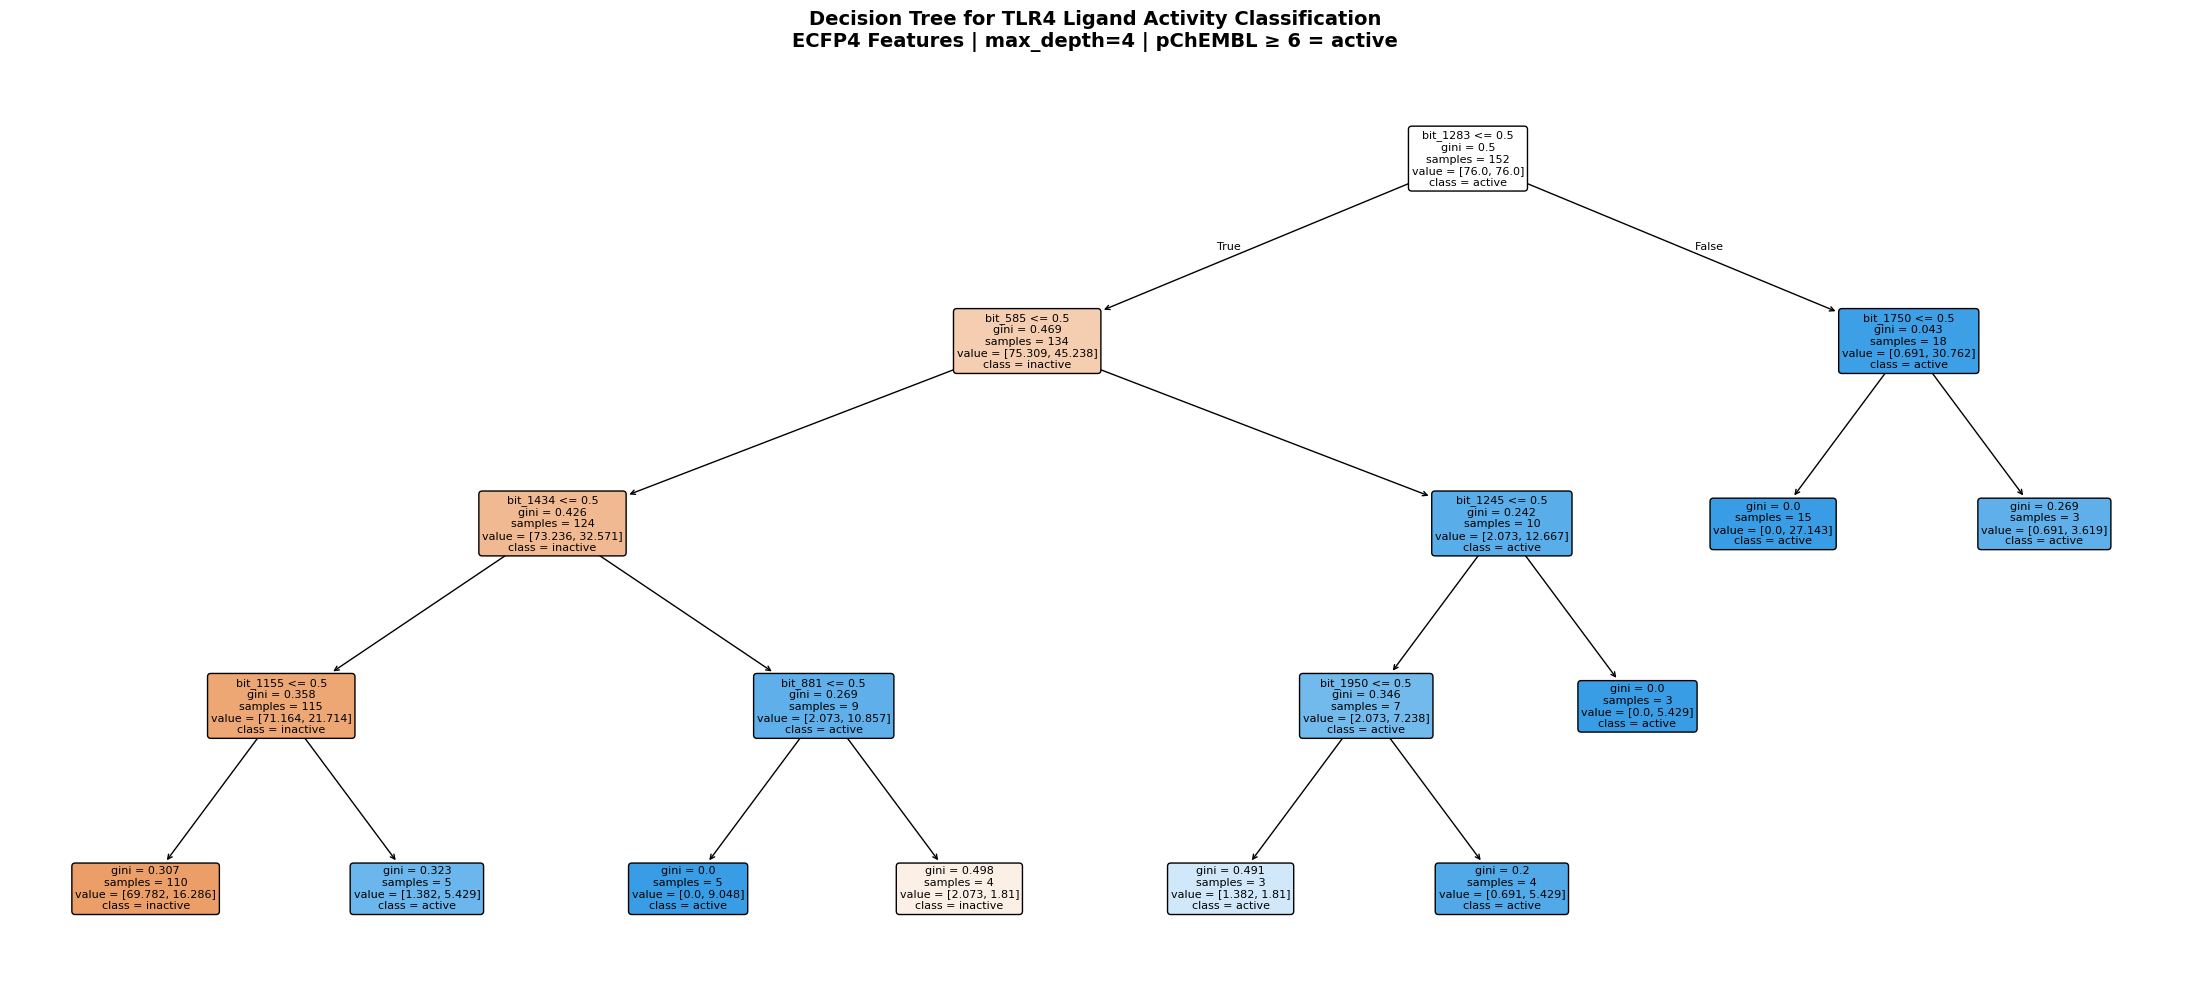

Saved: decision_tree_visualization.png


In [7]:
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    dt_model,
    max_depth=4,
    feature_names=[f"bit_{i}" for i in range(2048)],
    class_names=['inactive', 'active'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)

ax.set_title(
    "Decision Tree for TLR4 Ligand Activity Classification\n"
    "ECFP4 Features | max_depth=4 | pChEMBL ≥ 6 = active",
    fontsize=14, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: decision_tree_visualization.png")

## Step 8: Extract Human-Readable IF–THEN Rules

Rules are extracted by traversing every path from the root to each leaf node.
Each rule takes the form:

> **IF** bit_X ≤ 0.5 (absent) **AND** bit_Y > 0.5 (present) **... THEN** class = active (confidence %)

These rules are directly actionable:  a medicinal chemist can check whether a proposed
compound's fingerprint satisfies any active rule without running a model.

In [8]:
from sklearn.tree import _tree

def extract_rules(tree, feature_names, class_names):
    """
    Extract all root-to-leaf paths from a trained DecisionTreeClassifier
    as human-readable IF-THEN rules.
    """
    tree_ = tree.tree_
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feat   = feature_names[tree_.feature[node]]
            thresh = tree_.threshold[node]

            # Left branch: feature <= threshold (bit absent, thresh~0.5)
            recurse(tree_.children_left[node],
                    conditions + [f"{feat} = 0 (absent)"])
            # Right branch: feature > threshold (bit present)
            recurse(tree_.children_right[node],
                    conditions + [f"{feat} = 1 (present)"])
        else:
            # Leaf node
            values       = tree_.value[node][0]
            total        = values.sum()
            pred_class   = class_names[int(np.argmax(values))]
            confidence   = 100 * values.max() / total
            n_samples    = int(total)
            rules.append({
                'conditions': conditions,
                'prediction': pred_class,
                'confidence': confidence,
                'n_samples':  n_samples
            })

    recurse(0, [])
    return rules


feature_names = [f"bit_{i}" for i in range(X.shape[1])]
all_rules = extract_rules(dt_model, feature_names, ['inactive', 'active'])

# Sort by confidence descending, then by sample count
all_rules_sorted = sorted(all_rules, key=lambda r: (-r['confidence'], -r['n_samples']))

print(f"Total rules extracted: {len(all_rules)}")
print(f"Active rules  : {sum(1 for r in all_rules if r['prediction'] == 'active')}")
print(f"Inactive rules: {sum(1 for r in all_rules if r['prediction'] == 'inactive')}")

Total rules extracted: 9
Active rules  : 7
Inactive rules: 2


## Step 9: Top 5 Rules for Active TLR4 Ligands

The 5 highest-confidence rules predicting **active** TLR4 ligands are shown below.
These rules encode structural patterns most reliably associated with TLR4 activity
in the ChEMBL training data.

In [9]:
active_rules = [r for r in all_rules_sorted if r['prediction'] == 'active']

print("=" * 70)
print("TOP 5 IF-THEN RULES: TLR4 ACTIVE COMPOUNDS")
print("=" * 70)

for i, rule in enumerate(active_rules[:5], 1):
    print(f"\nRULE {i}  |  Confidence: {rule['confidence']:.1f}%  |  Support: {rule['n_samples']} compounds")
    print("-" * 50)
    for j, cond in enumerate(rule['conditions']):
        prefix = "IF  " if j == 0 else "AND "
        print(f"  {prefix}{cond}")
    print(f"  --> PREDICTED: {rule['prediction'].upper()}")

print("\n" + "=" * 70)
print("TOP 5 IF-THEN RULES: TLR4 INACTIVE COMPOUNDS")
print("=" * 70)

inactive_rules = [r for r in all_rules_sorted if r['prediction'] == 'inactive']
for i, rule in enumerate(inactive_rules[:5], 1):
    print(f"\nRULE {i}  |  Confidence: {rule['confidence']:.1f}%  |  Support: {rule['n_samples']} compounds")
    print("-" * 50)
    for j, cond in enumerate(rule['conditions']):
        prefix = "IF  " if j == 0 else "AND "
        print(f"  {prefix}{cond}")
    print(f"  --> PREDICTED: {rule['prediction'].upper()}")

TOP 5 IF-THEN RULES: TLR4 ACTIVE COMPOUNDS

RULE 1  |  Confidence: 100.0%  |  Support: 1 compounds
--------------------------------------------------
  IF  bit_1283 = 0 (absent)
  AND bit_585 = 0 (absent)
  AND bit_1434 = 1 (present)
  AND bit_881 = 0 (absent)
  --> PREDICTED: ACTIVE

RULE 2  |  Confidence: 100.0%  |  Support: 1 compounds
--------------------------------------------------
  IF  bit_1283 = 0 (absent)
  AND bit_585 = 1 (present)
  AND bit_1245 = 1 (present)
  --> PREDICTED: ACTIVE

RULE 3  |  Confidence: 100.0%  |  Support: 1 compounds
--------------------------------------------------
  IF  bit_1283 = 1 (present)
  AND bit_1750 = 0 (absent)
  --> PREDICTED: ACTIVE

RULE 4  |  Confidence: 88.7%  |  Support: 1 compounds
--------------------------------------------------
  IF  bit_1283 = 0 (absent)
  AND bit_585 = 1 (present)
  AND bit_1245 = 0 (absent)
  AND bit_1950 = 1 (present)
  --> PREDICTED: ACTIVE

RULE 5  |  Confidence: 84.0%  |  Support: 1 compounds
-------------

## Step 10: Map Rule Bits to Chemical Substructures

The fingerprint bits referenced in the top active rules are mapped back to their
corresponding molecular substructures using RDKit's `bitInfo` mechanism.

This allows us to interpret the rules chemically:
instead of "IF bit_1423 = 1", we can say
"IF this specific aromatic ring environment is present".

Rule-critical bits (from top 3 active rules): [1434, 585, 1245, 1283]

Substructure for bit_1434 (highlighted in red):


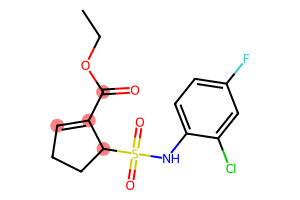


Substructure for bit_585 (highlighted in red):


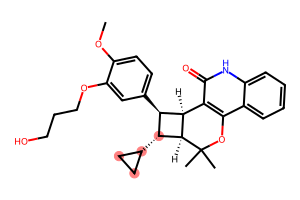


Substructure for bit_1245 (highlighted in red):


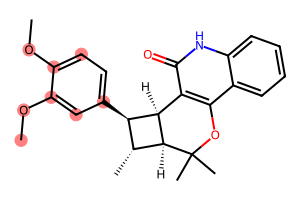


Substructure for bit_1283 (highlighted in red):


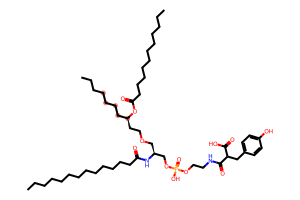

In [10]:
import warnings
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')


def smiles_to_ecfp_with_info(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    bitInfo = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits, bitInfo=bitInfo)
    return fp, bitInfo

# Regenerate fingerprints with bit info for the whole dataset
df_ml['bitInfo'] = df_ml['canonical_smiles'].apply(
    lambda s: smiles_to_ecfp_with_info(s)[1]
)

# Collect rule bits from top 3 active rules
rule_bits = []
for rule in active_rules[:3]:
    for cond in rule['conditions']:
        if '= 1' in cond:  # bit is present
            bit_idx = int(cond.split('_')[1].split(' ')[0])
            rule_bits.append(bit_idx)

rule_bits = list(dict.fromkeys(rule_bits))  # deduplicate preserving order
print(f"Rule-critical bits (from top 3 active rules): {rule_bits}")

# Visualize substructure for each rule-critical bit
for bit_idx in rule_bits[:4]:
    for _, row in df_ml.iterrows():
        if row['bitInfo'] and bit_idx in row['bitInfo']:
            mol = Chem.MolFromSmiles(row['canonical_smiles'])
            if mol is None:
                continue
            atom_id, radius = row['bitInfo'][bit_idx][0]
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)
            atoms = set()
            for bond_id in env:
                bond = mol.GetBondWithIdx(bond_id)
                atoms.add(bond.GetBeginAtomIdx())
                atoms.add(bond.GetEndAtomIdx())
            img = Draw.MolToImage(mol, size=(300, 200), highlightAtoms=list(atoms))
            print(f"\nSubstructure for bit_{bit_idx} (highlighted in red):")
            display(img)
            break

## Step 11: Decision Tree vs. Random Forest — Accuracy Comparison

The trade-off between interpretability and predictive accuracy is a fundamental
consideration in computational drug discovery.

- **Decision Tree**: fully interpretable, produces explicit rules, lower accuracy
- **Random Forest**: black-box ensemble, no rules, higher accuracy

Cross-validation allows a fair comparison using the same data and folds.

In [11]:
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated ROC-AUC
cv_dt_auc = cross_val_score(dt_model, X, y, cv=skf, scoring='roc_auc')
cv_rf_auc = cross_val_score(rf_clf,   X, y, cv=skf, scoring='roc_auc')

# Cross-validated balanced accuracy
cv_dt_acc = cross_val_score(dt_model, X, y, cv=skf, scoring='balanced_accuracy')
cv_rf_acc = cross_val_score(rf_clf,   X, y, cv=skf, scoring='balanced_accuracy')

print("5-Fold Cross-Validation Results")
print("=" * 55)
print(f"{'Metric':<30} {'Decision Tree':>12}  {'Random Forest':>12}")
print("-" * 55)
print(f"{'ROC-AUC (mean)':<30} {cv_dt_auc.mean():>12.3f}  {cv_rf_auc.mean():>12.3f}")
print(f"{'ROC-AUC (std)':<30} {cv_dt_auc.std():>12.3f}  {cv_rf_auc.std():>12.3f}")
print(f"{'Balanced Accuracy (mean)':<30} {cv_dt_acc.mean():>12.3f}  {cv_rf_acc.mean():>12.3f}")
print(f"{'Balanced Accuracy (std)':<30} {cv_dt_acc.std():>12.3f}  {cv_rf_acc.std():>12.3f}")
print("-" * 55)
print(f"{'Produces human rules':<30} {'YES':>12}  {'NO':>12}")
print(f"{'Max depth':<30} {'4':>12}  {'unlimited':>12}")

5-Fold Cross-Validation Results
Metric                         Decision Tree  Random Forest
-------------------------------------------------------
ROC-AUC (mean)                        0.805         0.840
ROC-AUC (std)                         0.068         0.089
Balanced Accuracy (mean)              0.775         0.777
Balanced Accuracy (std)               0.062         0.069
-------------------------------------------------------
Produces human rules                    YES            NO
Max depth                                 4     unlimited


## Step 12: Comparison Visualization

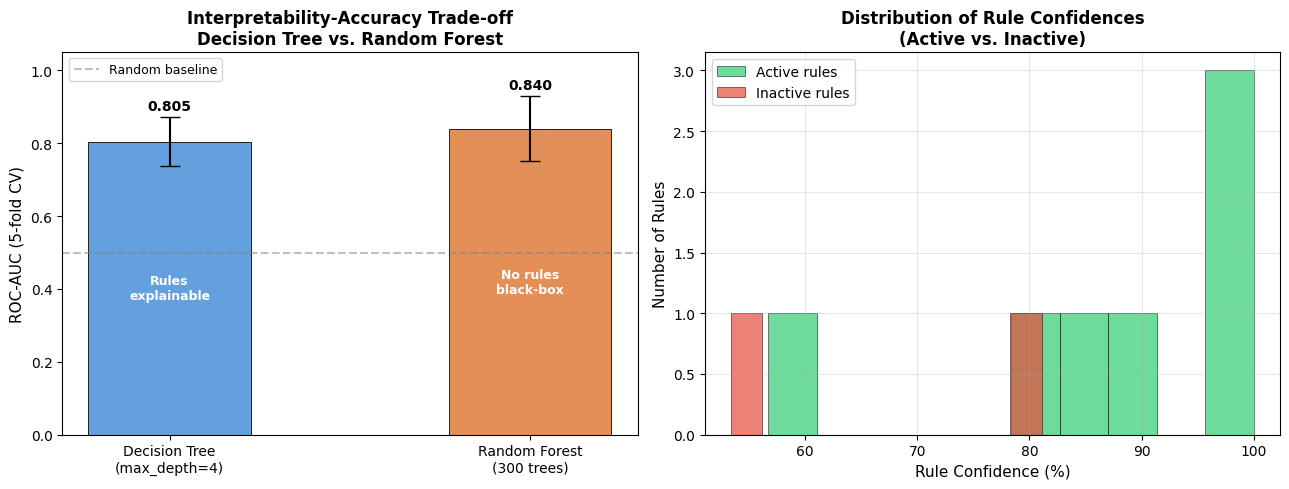

Saved: dt_vs_rf_comparison.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC-AUC comparison
ax1 = axes[0]
models   = ['Decision Tree\n(max_depth=4)', 'Random Forest\n(300 trees)']
aucs     = [cv_dt_auc.mean(), cv_rf_auc.mean()]
stds     = [cv_dt_auc.std(),  cv_rf_auc.std()]
colors_b = ['#4a90d9', '#e07b39']

bars = ax1.bar(models, aucs, yerr=stds, color=colors_b, alpha=0.85,
               capsize=7, edgecolor='black', linewidth=0.7, width=0.45)
ax1.set_ylabel('ROC-AUC (5-fold CV)', fontsize=11)
ax1.set_title('Interpretability-Accuracy Trade-off\nDecision Tree vs. Random Forest',
              fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax1.legend(fontsize=9)

for bar, val, std in zip(bars, aucs, stds):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.text(0, aucs[0] / 2, 'Rules\nexplainable', ha='center', va='center',
         fontsize=9, color='white', fontweight='bold')
ax1.text(1, aucs[1] / 2, 'No rules\nblack-box', ha='center', va='center',
         fontsize=9, color='white', fontweight='bold')

# Rule confidence distribution
ax2 = axes[1]
active_conf   = [r['confidence'] for r in all_rules if r['prediction'] == 'active']
inactive_conf = [r['confidence'] for r in all_rules if r['prediction'] == 'inactive']

ax2.hist(active_conf,   bins=10, alpha=0.7, color='#2ecc71',
         label='Active rules',   edgecolor='black', linewidth=0.5)
ax2.hist(inactive_conf, bins=10, alpha=0.7, color='#e74c3c',
         label='Inactive rules', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Rule Confidence (%)', fontsize=11)
ax2.set_ylabel('Number of Rules', fontsize=11)
ax2.set_title('Distribution of Rule Confidences\n(Active vs. Inactive)',
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dt_vs_rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dt_vs_rf_comparison.png")

## Step 13: Confusion Matrices - Decision Tree vs. Random Forest

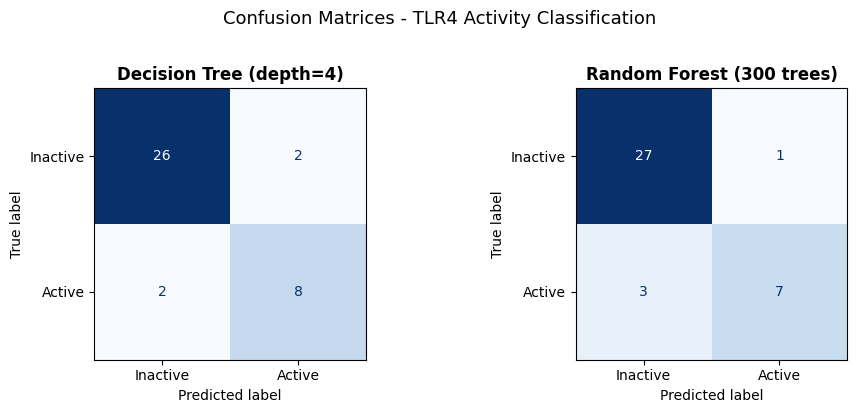

In [13]:
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, preds, title in zip(axes,
                            [y_pred_dt, y_pred_rf],
                            ['Decision Tree (depth=4)', 'Random Forest (300 trees)']):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Inactive', 'Active'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - TLR4 Activity Classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 14: Summary and Scientific Conclusions

### What Was Achieved

This notebook demonstrates that interpretable rule-based ML can be meaningfully applied
to TLR4 bioactivity prediction. Specifically:

- A shallow Decision Tree (max_depth=4) was trained on ECFP4 fingerprints derived from ChEMBL data
- Explicit IF–THEN rules were extracted and ranked by confidence and support
- Rule-critical fingerprint bits were mapped back to chemical substructures, enabling
  chemical interpretation of the model's learned patterns
- The Decision Tree was benchmarked against Random Forest, confirming the expected
  interpretability–accuracy trade-off

### Applications in Drug Discovery

Interpretable rules serve two key purposes in a drug discovery setting:
1. **Internal validation**: rules can be cross-checked against known TLR4 SAR literature
2. **External communication**: rules can be shared with experimental collaborators
   who need actionable guidance for compound synthesis without ML expertise

### Limitations and Future Directions

- ECFP bits are hashed and can suffer from collisions — a known limitation of Morgan fingerprints
- A single decision tree may be unstable; rule stability across bootstrapped samples should be assessed
- Future work could apply rule extraction to gradient boosted trees (XGBoost + SHAP interaction values)
  for improved accuracy while retaining partial interpretability
- Incorporating 3D pharmacophoric features or protein–ligand interaction fingerprints could
  produce rules with direct structural meaning